In [ ]:
import random, os
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


### Step 1: Data loading & EDA

Target mapping: {0: 'malignant', 1: 'benign'}

Class balance:
Class 0 (malignant): 212 (37.26%)
Class 1 (benign): 357 (62.74%)


C:\Users\riyya\AppData\Local\Temp\ipykernel_13868\1757220974.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette="pastel")


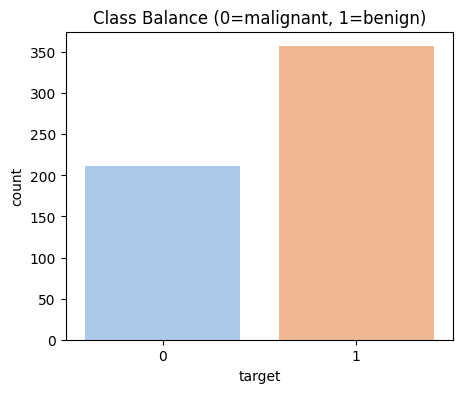

,mean,std
mean radius,14.127292,3.524049
mean texture,19.289649,4.301036
mean perimeter,91.969033,24.298981
mean area,654.889104,351.914129
mean smoothness,0.096360,0.014064


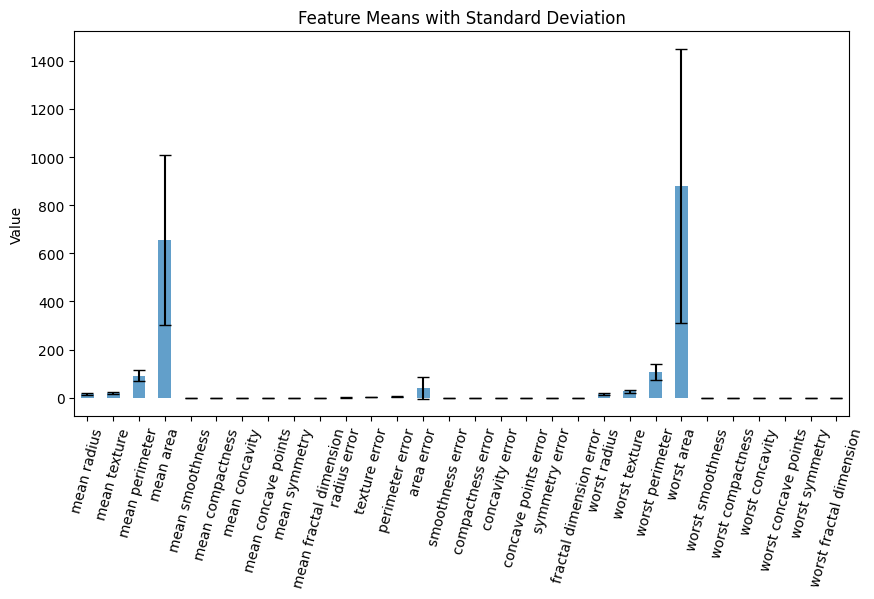

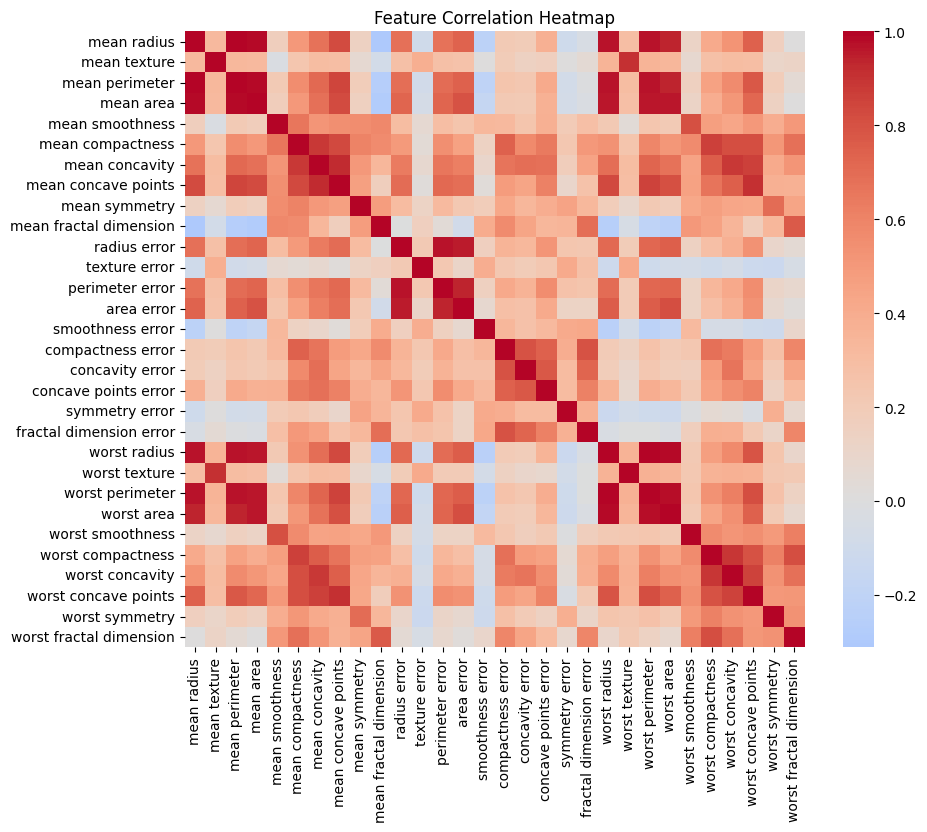

In [1]:

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# 1) Load dataset
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

# Confirm target mapping
ds = load_breast_cancer(as_frame=True)
target_mapping = {int(i): ds.target_names[int(i)] for i in sorted(pd.unique(ds.target))}
print("Target mapping:", target_mapping)

# 2) Class balance
class_counts = y.value_counts().sort_index()
print("\nClass balance:")
for cls, count in class_counts.items():
    print(f"Class {cls} ({target_mapping[cls]}): {count} ({count/len(y)*100:.2f}%)")

plt.figure(figsize=(5,4))
sns.countplot(x=y, palette="pastel")
plt.title("Class Balance (0=malignant, 1=benign)")
plt.show()

# 3) Feature summary (mean & std)
desc = X.describe().T[['mean', 'std']]
display(desc.head())  # show first few features, table will be large

plt.figure(figsize=(10,5))
desc['mean'].plot(kind="bar", yerr=desc['std'], alpha=0.7, capsize=4)
plt.title("Feature Means with Standard Deviation")
plt.ylabel("Value")
plt.xticks(rotation=75)
plt.show()

# 4) Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


### Step 2: Create two non-IID hospital splits

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# -------------------------------
# Load dataset again (with target mapping)
# -------------------------------
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target.map({0: "malignant", 1: "benign"})  # map target

df = pd.concat([X, y.rename("target")], axis=1)

# -------------------------------
# Step 1: Create external test set (20%)
# -------------------------------
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["target"], random_state=42
)

# -------------------------------
# Step 2: Split remaining into Hospital A & B (Option A: class imbalance)
# -------------------------------
# Separate malignant and benign
malignant = train_df[train_df["target"] == "malignant"]
benign = train_df[train_df["target"] == "benign"]

# Shuffle with fixed seed
rng = np.random.default_rng(seed=42)
malignant = malignant.sample(frac=1, random_state=42)
benign = benign.sample(frac=1, random_state=42)

# 60/40 split malignant → A/B
m_A = malignant.sample(frac=0.6, random_state=42)
m_B = malignant.drop(m_A.index)

# 60/40 split benign → B/A (to induce heterogeneity)
b_B = benign.sample(frac=0.6, random_state=42)
b_A = benign.drop(b_B.index)

# Combine splits
hospital_A = pd.concat([m_A, b_A]).sample(frac=1, random_state=42).reset_index(drop=True)
hospital_B = pd.concat([m_B, b_B]).sample(frac=1, random_state=42).reset_index(drop=True)

# -------------------------------
# Step 3: Save CSVs
# -------------------------------
hospital_A.to_csv("hospital_A.csv", index=False)
hospital_B.to_csv("hospital_B.csv", index=False)
test_df.to_csv("test_set.csv", index=False)

print("[OK] Saved hospital_A.csv, hospital_B.csv, test_set.csv")

# -------------------------------
# Step 4: Show class distribution per hospital
# -------------------------------
def summarize_classes(df, name):
    counts = df["target"].value_counts()
    total = len(df)
    return pd.DataFrame({
        "Hospital": [name],
        "Malignant (count)": [counts.get("malignant", 0)],
        "Malignant (%)": [100 * counts.get("malignant", 0) / total],
        "Benign (count)": [counts.get("benign", 0)],
        "Benign (%)": [100 * counts.get("benign", 0) / total],
        "Total": [total]
    })

summary = pd.concat([
    summarize_classes(hospital_A, "Hospital A"),
    summarize_classes(hospital_B, "Hospital B"),
    summarize_classes(test_df, "Test Set")
], ignore_index=True)

print("\nClass distribution per split:\n")
print(summary.to_string(index=False))


[OK] Saved hospital_A.csv, hospital_B.csv, test_set.csv

Class distribution per split:

  Hospital  Malignant (count)  Malignant (%)  Benign (count)  Benign (%)  Total
Hospital A                102      47.222222             114   52.777778    216
Hospital B                 68      28.451883             171   71.548117    239
  Test Set                 42      36.842105              72   63.157895    114


C:\Users\riyya\AppData\Local\Temp\ipykernel_13868\3431439025.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=hospital_A, ax=axes[0], palette="pastel")
C:\Users\riyya\AppData\Local\Temp\ipykernel_13868\3431439025.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=hospital_B, ax=axes[1], palette="pastel")
C:\Users\riyya\AppData\Local\Temp\ipykernel_13868\3431439025.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=test_df, ax=axes[2], palette="pastel")


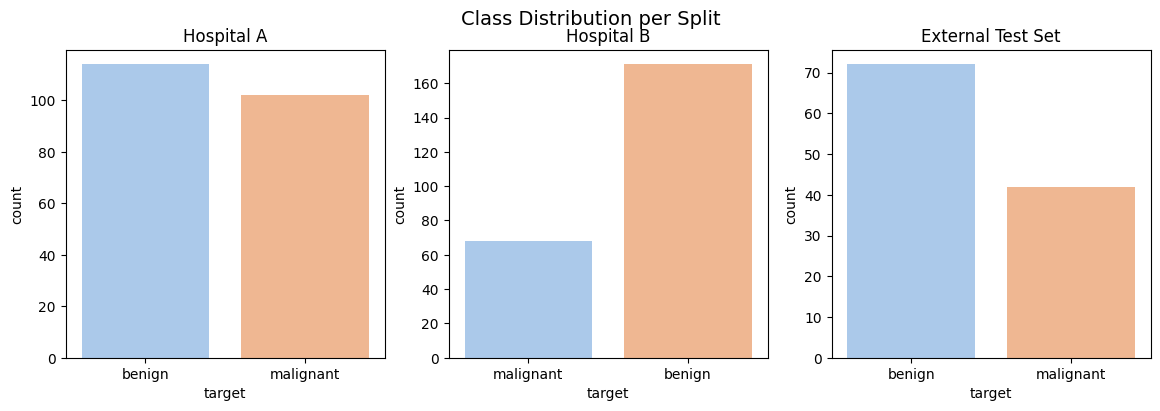

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(x="target", data=hospital_A, ax=axes[0], palette="pastel")
axes[0].set_title("Hospital A")

sns.countplot(x="target", data=hospital_B, ax=axes[1], palette="pastel")
axes[1].set_title("Hospital B")

sns.countplot(x="target", data=test_df, ax=axes[2], palette="pastel")
axes[2].set_title("External Test Set")

plt.suptitle("Class Distribution per Split", fontsize=14)
plt.show()

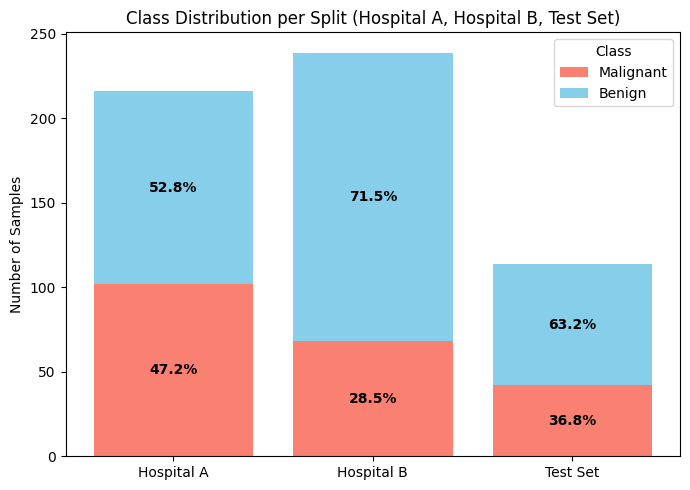

In [3]:
import matplotlib.pyplot as plt

# -------------------------------
# Step 5: Plot stacked bar (class distribution per hospital)
# -------------------------------
fig, ax = plt.subplots(figsize=(7, 5))

# Plot stacked bars
ax.bar(summary["Hospital"], summary["Malignant (count)"], 
       label="Malignant", color="salmon")
ax.bar(summary["Hospital"], summary["Benign (count)"], 
       bottom=summary["Malignant (count)"], label="Benign", color="skyblue")

# Add % labels inside bars
for idx, row in summary.iterrows():
    # Malignant %
    ax.text(idx, row["Malignant (count)"]/2,
            f'{row["Malignant (%)"]:.1f}%', 
            ha="center", va="center", color="black", fontsize=10, weight="bold")
    # Benign %
    ax.text(idx, row["Malignant (count)"] + row["Benign (count)"]/2,
            f'{row["Benign (%)"]:.1f}%', 
            ha="center", va="center", color="black", fontsize=10, weight="bold")

# Labels & style
ax.set_ylabel("Number of Samples")
ax.set_title("Class Distribution per Split (Hospital A, Hospital B, Test Set)")
ax.legend(title="Class")
plt.tight_layout()
plt.show()


### Step 3: Baseline Centralized Model (Reference)


Centralized Baseline Results:
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  Logistic Regression  0.973684        1.0  0.928571  0.962963  0.996362
1        Random Forest  0.964912        1.0  0.904762  0.950000  0.992725


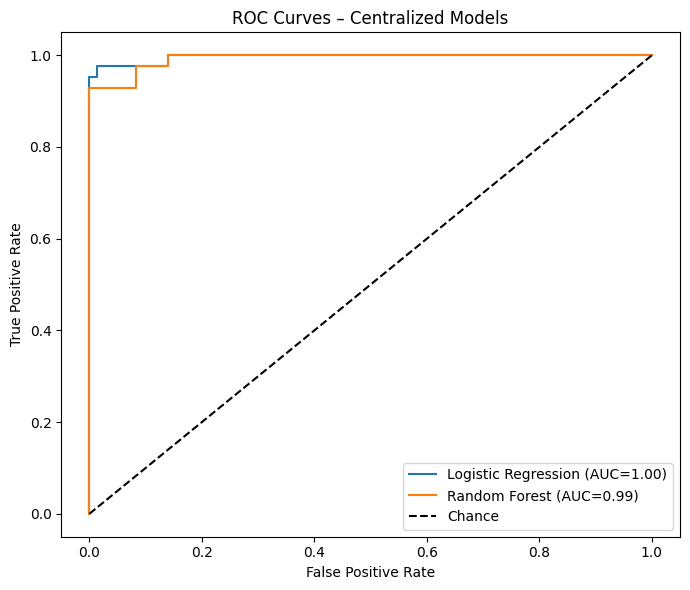


Best centralized model saved: Logistic Regression → models/centralized_best.joblib


In [4]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, roc_curve
)

# -------------------------------
# Prepare centralized train + external test
# -------------------------------
centralized_train = pd.concat([hospital_A, hospital_B], axis=0)
X = centralized_train.drop("target", axis=1)
y = centralized_train["target"]

# Train/validation split (for model tuning if needed)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# External test set (from Step 2: test_df)
X_test = test_df.drop("target", axis=1)
y_test = test_df["target"]

# -------------------------------
# Logistic Regression (with StandardScaler)
# -------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_scaled, y_train)

# -------------------------------
# Random Forest (raw features)
# -------------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# -------------------------------
# Evaluate on external test set
# -------------------------------
models = {
    "Logistic Regression": (lr, X_test_scaled),
    "Random Forest": (rf, X_test)
}

results = []
for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_proba = model.predict_proba(X_eval)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label="malignant")
    rec = recall_score(y_test, y_pred, pos_label="malignant")
    f1 = f1_score(y_test, y_pred, pos_label="malignant")
    roc_auc = roc_auc_score((y_test == "malignant").astype(int), y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)
print("\nCentralized Baseline Results:")
print(results_df)

# -------------------------------
# Plot ROC curves
# -------------------------------
plt.figure(figsize=(7, 6))
for name, (model, X_eval) in models.items():
    y_proba = model.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve((y_test == "malignant").astype(int), y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score((y_test == 'malignant').astype(int), y_proba):.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Centralized Models")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# Save best model (by ROC-AUC)
# -------------------------------
best_model_name = results_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
best_model, _ = models[best_model_name]

os.makedirs("models", exist_ok=True)  # ensure folder exists

if best_model_name == "Logistic Regression":
    joblib.dump({"model": best_model, "scaler": scaler}, "models/centralized_best.joblib")
else:
    joblib.dump(best_model, "models/centralized_best.joblib")

print(f"\nBest centralized model saved: {best_model_name} → models/centralized_best.joblib")


### Step 4: Federated learning without DP (Flower)

INFO flwr 2025-08-19 19:37:28,324 | app.py:163 | Starting Flower server, config: ServerConfig(num_rounds=10, round_timeout=None)
INFO flwr 2025-08-19 19:37:28,405 | app.py:176 | Flower ECE: gRPC server running (10 rounds), SSL is disabled
INFO flwr 2025-08-19 19:37:28,415 | server.py:89 | Initializing global parameters
INFO flwr 2025-08-19 19:37:28,417 | server.py:276 | Requesting initial parameters from one random client


[Server] Starting Flower server...


INFO flwr 2025-08-19 19:37:35,542 | grpc.py:52 | Opened insecure gRPC connection (no certificates were passed)
INFO flwr 2025-08-19 19:37:35,570 | grpc.py:52 | Opened insecure gRPC connection (no certificates were passed)
DEBUG flwr 2025-08-19 19:37:35,586 | connection.py:55 | ChannelConnectivity.IDLE
DEBUG flwr 2025-08-19 19:37:35,587 | connection.py:55 | ChannelConnectivity.READY
DEBUG flwr 2025-08-19 19:37:35,595 | connection.py:55 | ChannelConnectivity.IDLE
DEBUG flwr 2025-08-19 19:37:35,611 | connection.py:55 | ChannelConnectivity.READY
Exception in thread Thread-4 (start_server):
Traceback (most recent call last):
  File "C:\Users\riyya\anaconda3\envs\fedlearn\lib\threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "C:\Users\riyya\anaconda3\envs\fedlearn\lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "C:\Users\riyya\anaconda3\envs\fedlearn\lib\threading.py", line 953, in run
    self._target(*self._args, *

[OK] Saved global model to models\fed_nodp_final.pt
[Client A] Exception while starting client: FLClient.get_parameters() got an unexpected keyword argument 'config'


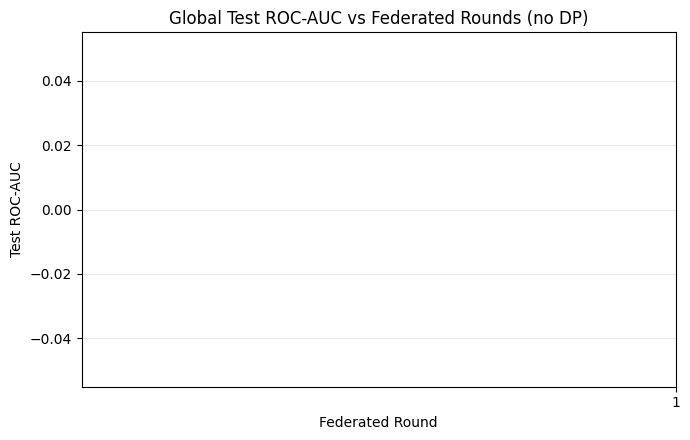

DEBUG flwr 2025-08-19 19:37:36,624 | connection.py:55 | ChannelConnectivity.IDLE


[OK] Saved ROC-AUC plot to plots\fed_nodp_roc_auc_vs_rounds.png

Final global model metrics (on external test set):
- Accuracy: 0.3684
- Precision: 0.3684
- Recall: 1.0000
- F1: 0.5385
- ROC-AUC: 0.9765


In [5]:
# fixed_fed_no_dp.py
# Federated learning (no DP) using Flower (fixed for newer flwr API)
# Requirements: flwr, torch, sklearn, pandas, numpy, matplotlib
# Run in the environment where hospital_A.csv, hospital_B.csv, test_set.csv (or DataFrames) exist.

import os
import threading
import time
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import flwr as fl  # Flower

# -----------------------------
# Configuration
# -----------------------------
ROUNDS = 10            # number of federated rounds (set 5-20 as required)
LOCAL_EPOCHS = 2       # local epochs per round (1-5)
BATCH_SIZE = 32
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUT_DIR = "models"
PLOTS_DIR = "plots"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# -----------------------------
# Helper: load datasets (from memory or CSV)
# -----------------------------
# If hospital_A/hospital_B/test_df exist in the notebook, use them; otherwise read CSVs.
try:
    hospital_A  # type: ignore
    hospital_B  # type: ignore
    test_df     # type: ignore
except NameError:
    hospital_A = pd.read_csv("hospital_A.csv")
    hospital_B = pd.read_csv("hospital_B.csv")
    test_df = pd.read_csv("test_set.csv")

# Convert string labels ("malignant"/"benign") to binary (malignant=1, benign=0) for training/ROC
label_map = {"malignant": 1, "benign": 0}
def df_to_dataloader(df: pd.DataFrame, batch_size=BATCH_SIZE, shuffle=True):
    X = df.drop("target", axis=1).values.astype(np.float32)
    y = df["target"].map(label_map).values.astype(np.float32)
    tensor_x = torch.from_numpy(X)
    tensor_y = torch.from_numpy(y).unsqueeze(1)  # BCEWithLogitsLoss expects [N,1]
    dataset = TensorDataset(tensor_x, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle), len(dataset)

train_loaders = {}
train_counts = {}

for name, df in [("A", hospital_A), ("B", hospital_B)]:
    loader, cnt = df_to_dataloader(df)
    train_loaders[name] = loader
    train_counts[name] = cnt

test_loader, test_count = df_to_dataloader(test_df, shuffle=False)

# -----------------------------
# Model definition (small MLP)
# -----------------------------
class SmallMLP(nn.Module):
    def __init__(self, n_features: int, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1)  # single logit (BCEWithLogitsLoss)
        )

    def forward(self, x):
        return self.net(x)

def get_model(n_features: int):
    model = SmallMLP(n_features).to(DEVICE)
    return model

# -----------------------------
# Parameter utilities (PyTorch <-> NumPy)
# -----------------------------
def get_weights(model: nn.Module) -> List[np.ndarray]:
    # Return list of numpy arrays of state_dict values (preserves order)
    return [val.cpu().detach().numpy() for _, val in model.state_dict().items()]

def set_weights(model: nn.Module, weights: List[np.ndarray]) -> None:
    # Load weights into model from list of numpy arrays (must match state_dict order)
    state_dict = model.state_dict()
    keys = list(state_dict.keys())
    if len(keys) != len(weights):
        raise ValueError("Mismatch between model state dict keys and provided weights.")
    new_state = {}
    for k, w in zip(keys, weights):
        new_state[k] = torch.tensor(w)
    model.load_state_dict(new_state)

# -----------------------------
# Flower client (PyTorch training locally)
# -----------------------------
class FLClient(fl.client.NumPyClient):
    def __init__(self, cid: str, model: nn.Module, train_loader: DataLoader):
        self.cid = cid
        self.model = model
        self.train_loader = train_loader
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=LR)

    def get_parameters(self) -> List[np.ndarray]:
        return get_weights(self.model)

    def fit(self, parameters: List[np.ndarray], config: Dict) -> Tuple[List[np.ndarray], int, Dict]:
        # set global weights
        set_weights(self.model, parameters)
        self.model.train()
        epochs = int(config.get("local_epochs", LOCAL_EPOCHS))
        for epoch in range(epochs):
            for X_batch, y_batch in self.train_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                self.optimizer.zero_grad()
                logits = self.model(X_batch)
                loss = self.criterion(logits, y_batch)
                loss.backward()
                self.optimizer.step()
        return get_weights(self.model), len(self.train_loader.dataset), {}

    def evaluate(self, parameters: List[np.ndarray], config: Dict) -> Tuple[float, int, Dict]:
        # Client-side evaluate (not used by server evaluation_fn, but required by NumPyClient)
        set_weights(self.model, parameters)
        self.model.eval()
        loss_total = 0.0
        n = 0
        with torch.no_grad():
            for X_batch, y_batch in self.train_loader:
                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                logits = self.model(X_batch)
                loss = self.criterion(logits, y_batch)
                loss_total += loss.item() * X_batch.size(0)
                n += X_batch.size(0)
        return (loss_total / n) if n > 0 else float("nan"), n, {}

# -----------------------------
# Server-side evaluation function (evaluate global model on external test set after each round)
# -----------------------------
n_features = hospital_A.shape[1] - 1  # minus target
global_model_for_eval = get_model(n_features)

roc_history: List[float] = []
round_counter = {"r": 0}  # mutable closure to keep round index if needed

def evaluate_fn(weights: List[np.ndarray]) -> Optional[Tuple[float, Dict[str, float]]]:
    """
    This function will be called by the Flower server after every round.
    Return (loss, {"roc_auc": float}) or None.
    """
    # update server-side global model
    set_weights(global_model_for_eval, weights)
    global_model_for_eval.eval()

    ys = []
    ys_proba = []
    criterion = nn.BCEWithLogitsLoss(reduction="sum")
    total_loss = 0.0
    total_n = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = global_model_for_eval(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item()
            total_n += X_batch.size(0)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            ys_proba.extend(probs.tolist())
            ys.extend(y_batch.cpu().numpy().ravel().tolist())

    try:
        roc = float(roc_auc_score(np.array(ys), np.array(ys_proba)))
    except Exception:
        roc = float("nan")

    avg_loss = total_loss / total_n if total_n > 0 else float("nan")
    roc_history.append(roc)
    round_counter["r"] += 1
    print(f"[Server] Round {round_counter['r']} — Test ROC-AUC: {roc:.4f} — Loss: {avg_loss:.4f}")
    return float(avg_loss), {"roc_auc": float(roc)}

# -----------------------------
# Start Flower server (in thread) and clients (in threads)
# -----------------------------
# Use ServerConfig for newer flwr API
strategy = fl.server.strategy.FedAvg(
    fraction_fit=1.0,      # both clients participate
    min_fit_clients=2,
    min_available_clients=2,
    evaluate_fn=evaluate_fn,  # server will call this after each round
)

def start_server():
    print("[Server] Starting Flower server...")
    # Use ServerConfig object for num_rounds (newer flwr API)
    fl.server.start_server(
        server_address="127.0.0.1:8080",
        config=fl.server.ServerConfig(num_rounds=ROUNDS),
        strategy=strategy,
    )
    print("[Server] Flower server finished.")

server_thread = threading.Thread(target=start_server, daemon=True)
server_thread.start()

# Wait a bit for server to be ready
time.sleep(2.0)

# Create fresh local models for each client
client_model_A = get_model(n_features)
client_model_B = get_model(n_features)

# Create client instances
client_A = FLClient(cid="A", model=client_model_A, train_loader=train_loaders["A"])
client_B = FLClient(cid="B", model=client_model_B, train_loader=train_loaders["B"])

# Start clients (use start_client with .to_client() to follow newer API)
def start_client(client: FLClient):
    try:
        fl.client.start_client(
            server_address="127.0.0.1:8080",
            client=client.to_client(),  # convert NumPyClient to new client object
        )
    except Exception as e:
        print(f"[Client {client.cid}] Exception while starting client: {e}")

t1 = threading.Thread(target=start_client, args=(client_A,), daemon=True)
t2 = threading.Thread(target=start_client, args=(client_B,), daemon=True)
t1.start()
t2.start()

# Wait for server to finish (blocking)
server_thread.join()

# -----------------------------
# After training: save final global model and plot ROC-AUC vs rounds
# -----------------------------
torch.save(global_model_for_eval.state_dict(), os.path.join(OUT_DIR, "fed_nodp_final.pt"))
print(f"[OK] Saved global model to {os.path.join(OUT_DIR, 'fed_nodp_final.pt')}")

# Plot ROC-AUC vs rounds
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(roc_history) + 1), roc_history, marker="o")
plt.xlabel("Federated Round")
plt.ylabel("Test ROC-AUC")
plt.title("Global Test ROC-AUC vs Federated Rounds (no DP)")
plt.xticks(range(1, max(1, len(roc_history)) + 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plot_path = os.path.join(PLOTS_DIR, "fed_nodp_roc_auc_vs_rounds.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Saved ROC-AUC plot to {plot_path}")

# Final evaluation metrics on test set (accuracy, precision, recall, f1, roc-auc)
global_model_for_eval.eval()
ys = []
ys_proba = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        logits = global_model_for_eval(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        ys_proba.extend(probs.tolist())
        ys.extend(y_batch.cpu().numpy().ravel().tolist())

y_true = np.array(ys).astype(int)
y_pred = (np.array(ys_proba) >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
final_metrics = {
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred, zero_division=0),
    "Recall": recall_score(y_true, y_pred, zero_division=0),
    "F1": f1_score(y_true, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_true, ys_proba),
}
print("\nFinal global model metrics (on external test set):")
for k, v in final_metrics.items():
    print(f"- {k}: {v:.4f}")

# Done


### Step 5: Federated learning with Differential Privacy (Opacus)

INFO flwr 2025-08-19 20:11:22,941 | app.py:163 | Starting Flower server, config: ServerConfig(num_rounds=10, round_timeout=None)
08/19/2025 20:11:22:INFO:Starting Flower server, config: ServerConfig(num_rounds=10, round_timeout=None)
INFO flwr 2025-08-19 20:11:23,002 | app.py:176 | Flower ECE: gRPC server running (10 rounds), SSL is disabled
08/19/2025 20:11:23:INFO:Flower ECE: gRPC server running (10 rounds), SSL is disabled
INFO flwr 2025-08-19 20:11:23,002 | server.py:89 | Initializing global parameters
08/19/2025 20:11:23:INFO:Initializing global parameters
INFO flwr 2025-08-19 20:11:23,009 | server.py:276 | Requesting initial parameters from one random client
08/19/2025 20:11:23:INFO:Requesting initial parameters from one random client


[Client A] init: dataset size=216
[Client A] Attaching Opacus PrivacyEngine (sigma=1.0, C=1.0)
[Client B] init: dataset size=239
[Client B] Attaching Opacus PrivacyEngine (sigma=1.0, C=1.0)


C:\Users\riyya\anaconda3\envs\fedlearn\lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
INFO flwr 2025-08-19 20:11:24,989 | grpc.py:52 | Opened insecure gRPC connection (no certificates were passed)
08/19/2025 20:11:24:INFO:Opened insecure gRPC connection (no certificates were passed)
INFO flwr 2025-08-19 20:11:25,063 | grpc.py:52 | Opened insecure gRPC connection (no certificates were passed)
08/19/2025 20:11:25:INFO:Opened insecure gRPC connection (no certificates were passed)
DEBUG flwr 2025-08-19 20:11:25,127 | connection.py:55 | ChannelConnectivity.IDLE
08/19/2025 20:11:25:DEBUG:ChannelConnectivity.IDLE
DEBUG flwr 2025-08-19 20:11:25,141 | connection.py:55 | ChannelConnectivity.IDLE
08/19/2025 20:11:25:DEBUG:ChannelConnectivity.IDLE
DEBU

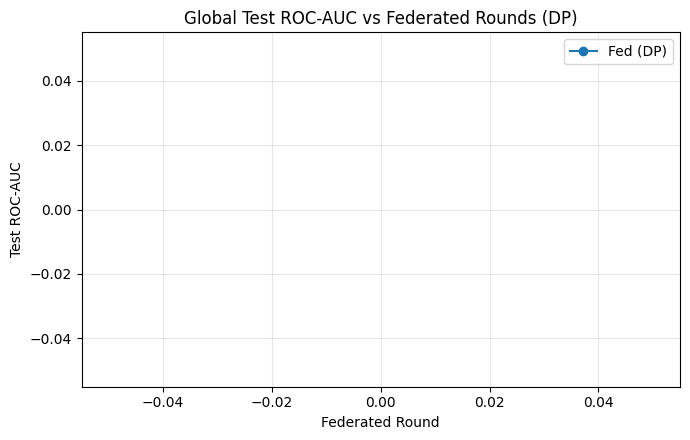

DEBUG flwr 2025-08-19 20:11:26,157 | connection.py:55 | ChannelConnectivity.IDLE
08/19/2025 20:11:26:DEBUG:ChannelConnectivity.IDLE
INFO flwr 2025-08-19 20:11:26,365 | grpc.py:52 | Opened insecure gRPC connection (no certificates were passed)
08/19/2025 20:11:26:INFO:Opened insecure gRPC connection (no certificates were passed)
DEBUG flwr 2025-08-19 20:11:26,383 | connection.py:55 | ChannelConnectivity.IDLE
08/19/2025 20:11:26:DEBUG:ChannelConnectivity.IDLE
DEBUG flwr 2025-08-19 20:11:26,391 | connection.py:55 | ChannelConnectivity.CONNECTING
08/19/2025 20:11:26:DEBUG:ChannelConnectivity.CONNECTING
DEBUG flwr 2025-08-19 20:11:28,421 | connection.py:55 | ChannelConnectivity.TRANSIENT_FAILURE
08/19/2025 20:11:28:DEBUG:ChannelConnectivity.TRANSIENT_FAILURE
DEBUG flwr 2025-08-19 20:11:28,636 | connection.py:220 | gRPC channel closed
08/19/2025 20:11:28:DEBUG:gRPC channel closed
INFO flwr 2025-08-19 20:11:29,657 | grpc.py:52 | Opened insecure gRPC connection (no certificates were passed)
08

In [14]:
# step5_fed_with_dp_verbose.py
# Federated learning WITH Differential Privacy (Opacus) using Flower clients
# - Robust Flower <-> Opacus wiring
# - Uses make_private
# - Safer delta = 1/N
# - Collects y_true_dp, ys_proba_dp for ROC curve later
# - Saves ROC history and per-round results

import os
import time
import threading
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import flwr as fl
from flwr.common import ndarrays_to_parameters, parameters_to_ndarrays
from opacus import PrivacyEngine

# -----------------------------
# Config
# -----------------------------
ROUNDS = 10
LOCAL_EPOCHS = 2
BATCH_SIZE = 32
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DP params
CLIP_NORM = 1.0
NOISE_MULTIPLIER = 1.0

OUT_DIR = "models"
PLOTS_DIR = "plots"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

SERVER_ADDR = "127.0.0.1:8085"  # changed port to avoid conflicts

# -----------------------------
# Load CSV splits (created in step 2)
# -----------------------------
hospital_A = pd.read_csv("hospital_A.csv")
hospital_B = pd.read_csv("hospital_B.csv")
test_df = pd.read_csv("test_set.csv")

label_map = {"malignant": 1, "benign": 0}


def df_to_dataloader(df: pd.DataFrame, batch_size=BATCH_SIZE, shuffle=True):
    X = df.drop("target", axis=1).values.astype(np.float32)
    y = df["target"].map(label_map).values.astype(np.float32)
    tensor_x = torch.from_numpy(X)
    tensor_y = torch.from_numpy(y).unsqueeze(1)
    dataset = TensorDataset(tensor_x, tensor_y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle), len(dataset), dataset


train_loaders, train_counts, train_datasets = {}, {}, {}
for name, df in [("A", hospital_A), ("B", hospital_B)]:
    loader, cnt, ds = df_to_dataloader(df, batch_size=BATCH_SIZE, shuffle=True)
    train_loaders[name] = loader
    train_counts[name] = cnt
    train_datasets[name] = ds

test_loader, test_count, _ = df_to_dataloader(test_df, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# Model
# -----------------------------
class SmallMLP(nn.Module):
    def __init__(self, n_features: int, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )

    def forward(self, x):
        return self.net(x)


def get_model(n_features: int):
    return SmallMLP(n_features).to(DEVICE)


# -----------------------------
# Utils to convert weights <-> Parameters
# -----------------------------
def get_weights(model: nn.Module) -> List[np.ndarray]:
    return [val.cpu().detach().numpy() for _, val in model.state_dict().items()]


def set_weights(model: nn.Module, weights: List[np.ndarray]) -> None:
    state_dict = model.state_dict()
    keys = list(state_dict.keys())
    new_state = {k: torch.tensor(w) for k, w in zip(keys, weights)}
    model.load_state_dict(new_state)


# -----------------------------
# DP-enabled Flower NumPyClient
# -----------------------------
class FLClientDP(fl.client.NumPyClient):
    def __init__(self, cid, model, train_loader, train_dataset, noise_multiplier, max_grad_norm):
        self.cid = cid
        self.model = model
        self.train_loader = train_loader
        self.train_dataset = train_dataset
        self.noise_multiplier = noise_multiplier
        self.max_grad_norm = max_grad_norm
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=LR)
        self.privacy_engine: Optional[PrivacyEngine] = None
        print(f"[Client {self.cid}] init: dataset size={len(self.train_dataset)}", flush=True)
        self._attach_privacy_engine()

    def _attach_privacy_engine(self):
        print(f"[Client {self.cid}] Attaching Opacus PrivacyEngine (sigma={self.noise_multiplier}, C={self.max_grad_norm})",
              flush=True)
        self.privacy_engine = PrivacyEngine()
        self.model, self.optimizer, self.train_loader = self.privacy_engine.make_private(
            module=self.model,
            optimizer=self.optimizer,
            data_loader=self.train_loader,
            noise_multiplier=self.noise_multiplier,
            max_grad_norm=self.max_grad_norm,
        )

    def get_parameters(self, ins=None):
        return ndarrays_to_parameters(get_weights(self.model))

    def fit(self, parameters, config):
        try:
            nd = parameters_to_ndarrays(parameters)
        except Exception:
            nd = parameters
        set_weights(self.model, nd)
        self.model.train()
        epochs = int(config.get("local_epochs", LOCAL_EPOCHS))
        for epoch in range(epochs):
            for X_batch, y_batch in self.train_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                self.optimizer.zero_grad()
                loss = self.criterion(self.model(X_batch), y_batch)
                loss.backward()
                self.optimizer.step()
        return ndarrays_to_parameters(get_weights(self.model)), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        try:
            nd = parameters_to_ndarrays(parameters)
        except Exception:
            nd = parameters
        set_weights(self.model, nd)
        self.model.eval()
        total_loss, n = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in self.train_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                total_loss += self.criterion(self.model(X_batch), y_batch).item() * X_batch.size(0)
                n += X_batch.size(0)
        return total_loss / n, n, {}

    def get_epsilon_delta(self, delta: float):
        if self.privacy_engine is None:
            return float("nan"), delta
        try:
            eps = self.privacy_engine.get_privacy_spent(delta)[0]
        except Exception:
            try:
                eps = self.privacy_engine.accountant.get_epsilon(delta)
            except Exception:
                eps = float("nan")
        return eps, delta


# -----------------------------
# Server evaluation (global test)
# -----------------------------
n_features = hospital_A.shape[1] - 1
global_model_for_eval = get_model(n_features)

roc_history_dp: List[float] = []
round_counter = {"r": 0}
# Keep full predictions for final ROC curve
y_true_dp, ys_proba_dp = [], []


def evaluate_fn_dp(weights):
    try:
        nd = parameters_to_ndarrays(weights)
    except Exception:
        nd = weights
    set_weights(global_model_for_eval, nd)
    global_model_for_eval.eval()
    ys, ys_proba = [], []
    criterion = nn.BCEWithLogitsLoss(reduction="sum")
    total_loss, total_n = 0.0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = global_model_for_eval(X_batch)
            total_loss += criterion(logits, y_batch).item()
            total_n += X_batch.size(0)
            ys_proba.extend(torch.sigmoid(logits).cpu().numpy().ravel())
            ys.extend(y_batch.cpu().numpy().ravel())
    try:
        roc = float(roc_auc_score(np.array(ys), np.array(ys_proba)))
    except Exception:
        roc = float("nan")
    roc_history_dp.append(roc)
    round_counter["r"] += 1
    # Store last round full preds
    if round_counter["r"] == ROUNDS:
        y_true_dp.extend(ys)
        ys_proba_dp.extend(ys_proba)
    print(f"[Server] After round {round_counter['r']}: TEST ROC-AUC = {roc:.4f}", flush=True)
    return total_loss / total_n, {"roc_auc": roc}


strategy_dp = fl.server.strategy.FedAvg(
    fraction_fit=1.0, min_fit_clients=2, min_available_clients=2, evaluate_fn=evaluate_fn_dp
)


def start_server_dp():
    fl.server.start_server(
        server_address=SERVER_ADDR,
        config=fl.server.ServerConfig(num_rounds=ROUNDS),
        strategy=strategy_dp,
    )


server_thread = threading.Thread(target=start_server_dp, daemon=True)
server_thread.start()
time.sleep(2.0)

client_A = FLClientDP("A", get_model(n_features), train_loaders["A"], train_datasets["A"], NOISE_MULTIPLIER, CLIP_NORM)
client_B = FLClientDP("B", get_model(n_features), train_loaders["B"], train_datasets["B"], NOISE_MULTIPLIER, CLIP_NORM)


def start_client_with_retry(client_obj, retries=5, delay=1.0):
    for _ in range(retries):
        try:
            fl.client.start_client(server_address=SERVER_ADDR, client=client_obj)
            return
        except Exception as e:
            time.sleep(delay)


t1 = threading.Thread(target=start_client_with_retry, args=(client_A,), daemon=True)
t2 = threading.Thread(target=start_client_with_retry, args=(client_B,), daemon=True)
t1.start()
t2.start()

server_thread.join()

# Save model + ROC history + preds
torch.save(global_model_for_eval.state_dict(), os.path.join(OUT_DIR, "fed_dp_final.pt"))
np.save(os.path.join(PLOTS_DIR, "fed_dp_roc_history.npy"), np.array(roc_history_dp))
np.save(os.path.join(PLOTS_DIR, "fed_dp_y_true.npy"), np.array(y_true_dp))
np.save(os.path.join(PLOTS_DIR, "fed_dp_y_proba.npy"), np.array(ys_proba_dp))

# Plot ROC-AUC vs rounds
plt.figure(figsize=(7, 4.5))
plt.plot(np.arange(1, len(roc_history_dp) + 1), roc_history_dp, marker="o", label="Fed (DP)")
plt.xlabel("Federated Round")
plt.ylabel("Test ROC-AUC")
plt.title("Global Test ROC-AUC vs Federated Rounds (DP)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "fed_dp_roc_auc_vs_rounds.png"), dpi=150)
plt.show()


### Step 6: Comparative analysis

C:\Users\riyya\anaconda3\envs\fedlearn\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Comparative results saved to results\comparative_results.csv
                          Model  Accuracy  Precision  Recall      F1  ROC-AUC  \
Method                                                                          
Centralized  LogisticRegression    0.9737     1.0000  0.9286  0.9630   0.9964   
Fed (no-DP)            SmallMLP    0.3684     0.3684  1.0000  0.5385   0.9765   
Fed (DP)               SmallMLP    0.3684     0.3684  1.0000  0.5385   0.9555   

            Train time    ε    δ clip_norm noise_mult  
Method                                                 
Centralized        N/A                                 
Fed (no-DP)        N/A                                 
Fed (DP)           N/A  NaN  NaN       NaN        NaN  


<Figure size 800x450 with 0 Axes>

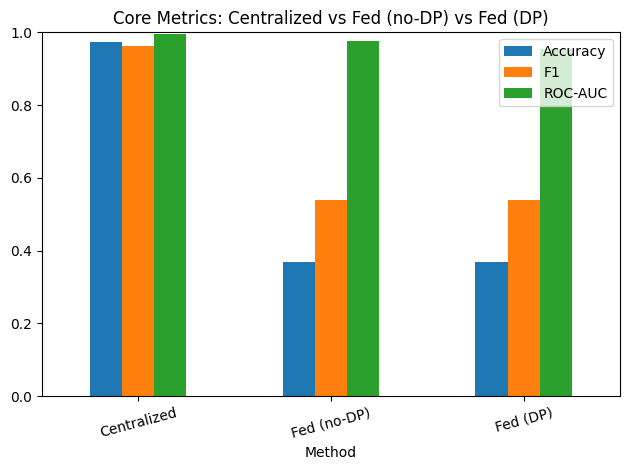

[OK] Saved metrics bar chart → results\comparative_metrics.png


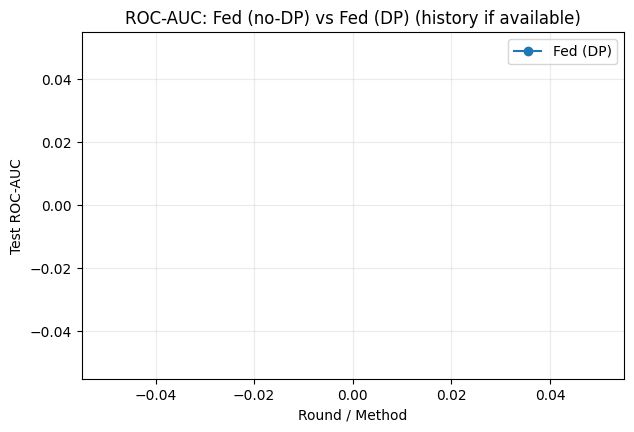

[OK] Saved ROC-AUC comparison plot → results\comparative_roc_auc.png

--- Discussion prompts & starter answers ---

1) Where did accuracy drop most and why?
- Starter: Most accuracy drop (if observed) happens in Federated + DP due to gradient clipping and noise addition (DP-SGD) which reduces model signal. Federated (no-DP) may also be slightly worse than centralized due to heterogeneity / smaller local sample sizes per client.

2) How sensitive are results to noise multiplier and clipping norm?
- Starter: Noise multiplier (σ) strongly trades privacy vs utility: higher σ → stronger privacy (smaller effective ε) but larger performance hit. Clipping norm (C) controls gradient sensitivity: too small C truncates information; too large C reduces DP effect. Empirically tune C and σ; small grid search on a held-out fold is recommended.

3) Would more rounds or more clients help?
- Starter: More rounds typically help convergence (especially for DP where noise slows learning). More clients incr

In [15]:
# step6_comparative_analysis.py
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, Any

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

import torch
import torch.nn as nn

# -----------------------------
# Paths & files (adjust if needed)
# -----------------------------
TEST_CSV = "test_set.csv"
CENTRALIZED_JOBLIB = "models/centralized_best.joblib"
FED_NODP_PT = "models/fed_nodp_final.pt"
FED_DP_PT = "models/fed_dp_final.pt"
FED_NODP_ROC_HISTORY = "plots/fed_nodp_roc_history.npy"
FED_DP_ROC_HISTORY = "plots/fed_dp_roc_history.npy"

OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

# Optional metadata files (may not exist)
TRAINING_TIMES_JSON = os.path.join("results", "training_times.json")     # optional: {"centralized": "10s/epoch", "fed_nodp": "20s/round", "fed_dp": "25s/round"}
PRIVACY_REPORT_JSON = os.path.join("results", "privacy_report.json")     # optional: {"fed_dp": {"epsilon": 5.3, "delta": 0.0001, "clip_norm": 1.0, "noise_mult": 1.0}}

# -----------------------------
# Load test set
# -----------------------------
test_df = pd.read_csv(TEST_CSV)
# ensure consistent mapping: malignant=1, benign=0 for torch models & metrics
label_to_int = {"malignant": 1, "benign": 0}
y_true = test_df["target"].map(label_to_int).values
X_test = test_df.drop(columns=["target"]).values.astype(np.float32)
feature_names = test_df.drop(columns=["target"]).columns.tolist()

# -----------------------------
# Centralized model loader & eval
# -----------------------------
def evaluate_centralized(joblib_path: str, X_test_np: np.ndarray, y_true_np: np.ndarray) -> Dict[str, Any]:
    """Load joblib. Handles two formats:
    - {'model': model, 'scaler': scaler}  -> LogisticRegression saved this way
    - RandomForestClassifier saved directly
    """
    if not os.path.exists(joblib_path):
        return {"exists": False}
    obj = joblib.load(joblib_path)
    # Determine type
    if isinstance(obj, dict) and "model" in obj and "scaler" in obj:
        model = obj["model"]
        scaler = obj["scaler"]
        X_eval = scaler.transform(X_test_np)
    else:
        model = obj
        X_eval = X_test_np
    # predict_proba may not exist for some models, guard
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_eval)[:, 1]
    else:
        # fallback: use decision_function or deterministic predictions
        if hasattr(model, "decision_function"):
            scores = model.decision_function(X_eval)
            # scale scores to 0-1 via min-max for ROC only — not ideal but fallback
            proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            proba = model.predict(X_eval)
    preds = (proba >= 0.5).astype(int)
    acc = accuracy_score(y_true_np, preds)
    prec = precision_score(y_true_np, preds, zero_division=0)
    rec = recall_score(y_true_np, preds, zero_division=0)
    f1 = f1_score(y_true_np, preds, zero_division=0)
    try:
        roc_auc = roc_auc_score(y_true_np, proba)
    except Exception:
        roc_auc = float("nan")
    return {
        "exists": True,
        "model_type": type(model).__name__,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "y_proba": proba
    }

central_res = evaluate_centralized(CENTRALIZED_JOBLIB, X_test, y_true)

# -----------------------------
# PyTorch MLP definition (must match training)
# -----------------------------
class SmallMLP(nn.Module):
    def __init__(self, n_features: int, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )
    def forward(self, x):
        return self.net(x)

def evaluate_torch_model(pt_path: str, X_test_np: np.ndarray, y_true_np: np.ndarray, device=None) -> Dict[str, Any]:
    if not os.path.exists(pt_path):
        return {"exists": False}
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    n_features = X_test_np.shape[1]
    model = SmallMLP(n_features).to(device)
    # load state dict (handle plain state_dict or full model)
    try:
        state = torch.load(pt_path, map_location=device)
        # state may be dict of parameters or a whole state_dict
        if isinstance(state, dict) and any(k.startswith("net") or k.startswith("0") or "weight" in k for k in state.keys()):
            # likely state_dict
            model.load_state_dict(state)
        else:
            # might be raw torch.save(model.state_dict()) which is state_dict as well
            model.load_state_dict(state)
    except Exception as e:
        # try loading as a whole model (rare)
        try:
            model = torch.load(pt_path, map_location=device)
        except Exception as e2:
            return {"exists": False, "error": str(e2)}
    model.eval()
    with torch.no_grad():
        X_tensor = torch.from_numpy(X_test_np).to(device)
        logits = model(X_tensor).cpu().numpy().ravel()
        proba = 1.0 / (1.0 + np.exp(-logits))  # sigmoid
        preds = (proba >= 0.5).astype(int)
    acc = accuracy_score(y_true_np, preds)
    prec = precision_score(y_true_np, preds, zero_division=0)
    rec = recall_score(y_true_np, preds, zero_division=0)
    f1 = f1_score(y_true_np, preds, zero_division=0)
    try:
        roc_auc = roc_auc_score(y_true_np, proba)
    except Exception:
        roc_auc = float("nan")
    return {
        "exists": True,
        "model_type": "SmallMLP",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "y_proba": proba
    }

fed_nodp_res = evaluate_torch_model(FED_NODP_PT, X_test, y_true)
fed_dp_res = evaluate_torch_model(FED_DP_PT, X_test, y_true)

# -----------------------------
# Training times & privacy (optional files)
# -----------------------------
training_times = {"centralized": "N/A", "fed_nodp": "N/A", "fed_dp": "N/A"}
if os.path.exists(TRAINING_TIMES_JSON):
    try:
        with open(TRAINING_TIMES_JSON, "r") as f:
            training_times.update(json.load(f))
    except Exception:
        pass

privacy_info = {"fed_dp": {"epsilon": float("nan"), "delta": float("nan"), "clip_norm": float("nan"), "noise_mult": float("nan")}}
if os.path.exists(PRIVACY_REPORT_JSON):
    try:
        with open(PRIVACY_REPORT_JSON, "r") as f:
            privacy_info.update(json.load(f))
    except Exception:
        pass

# -----------------------------
# Compile comparative DataFrame
# -----------------------------
methods = []
rows = []
# Centralized
if central_res.get("exists", False):
    methods.append("Centralized")
    rows.append({
        "Method": "Centralized",
        "Model": central_res.get("model_type", "Centralized"),
        "Accuracy": central_res["Accuracy"],
        "Precision": central_res["Precision"],
        "Recall": central_res["Recall"],
        "F1": central_res["F1"],
        "ROC-AUC": central_res["ROC-AUC"],
        "Train time": training_times.get("centralized", "N/A"),
        "ε": "", "δ": "", "clip_norm": "", "noise_mult": ""
    })
else:
    print("Warning: centralized model not found at", CENTRALIZED_JOBLIB)

# Fed no-DP
if fed_nodp_res.get("exists", False):
    methods.append("Fed (no-DP)")
    rows.append({
        "Method": "Fed (no-DP)",
        "Model": fed_nodp_res.get("model_type", "SmallMLP"),
        "Accuracy": fed_nodp_res["Accuracy"],
        "Precision": fed_nodp_res["Precision"],
        "Recall": fed_nodp_res["Recall"],
        "F1": fed_nodp_res["F1"],
        "ROC-AUC": fed_nodp_res["ROC-AUC"],
        "Train time": training_times.get("fed_nodp", "N/A"),
        "ε": "", "δ": "", "clip_norm": "", "noise_mult": ""
    })
else:
    print("Warning: fed no-DP model not found at", FED_NODP_PT)

# Fed DP
if fed_dp_res.get("exists", False):
    dp_meta = privacy_info.get("fed_dp", {})
    methods.append("Fed (DP)")
    rows.append({
        "Method": "Fed (DP)",
        "Model": fed_dp_res.get("model_type", "SmallMLP"),
        "Accuracy": fed_dp_res["Accuracy"],
        "Precision": fed_dp_res["Precision"],
        "Recall": fed_dp_res["Recall"],
        "F1": fed_dp_res["F1"],
        "ROC-AUC": fed_dp_res["ROC-AUC"],
        "Train time": training_times.get("fed_dp", "N/A"),
        "ε": dp_meta.get("epsilon", float("nan")),
        "δ": dp_meta.get("delta", float("nan")),
        "clip_norm": dp_meta.get("clip_norm", float("nan")),
        "noise_mult": dp_meta.get("noise_mult", float("nan"))
    })
else:
    print("Warning: fed DP model not found at", FED_DP_PT)

comp_df = pd.DataFrame(rows).set_index("Method").round(4)
comp_df.to_csv(os.path.join(OUT_DIR, "comparative_results.csv"))
print("\nComparative results saved to", os.path.join(OUT_DIR, "comparative_results.csv"))
print(comp_df)

# -----------------------------
# Plot: Bar chart of core metrics (Accuracy, F1, ROC-AUC)
# -----------------------------
metrics_to_plot = ["Accuracy", "F1", "ROC-AUC"]
plt.figure(figsize=(8,4.5))
bar_df = comp_df[metrics_to_plot].astype(float)
bar_df.plot(kind="bar", rot=15)
plt.title("Core Metrics: Centralized vs Fed (no-DP) vs Fed (DP)")
plt.ylim(0,1.0)
plt.tight_layout()
out_bar = os.path.join(OUT_DIR, "comparative_metrics.png")
plt.savefig(out_bar, dpi=150)
plt.show()
print(f"[OK] Saved metrics bar chart → {out_bar}")

# -----------------------------
# Plot: ROC-AUC history vs rounds (if histories exist)
# -----------------------------
plt.figure(figsize=(7,4.5))
plotted = False
if os.path.exists(FED_NODP_ROC_HISTORY):
    try:
        nodp_hist = np.load(FED_NODP_ROC_HISTORY)
        plt.plot(np.arange(1, len(nodp_hist)+1), nodp_hist, marker="o", label="Fed (no-DP)")
        plotted = True
    except Exception:
        pass
if os.path.exists(FED_DP_ROC_HISTORY):
    try:
        dp_hist = np.load(FED_DP_ROC_HISTORY)
        plt.plot(np.arange(1, len(dp_hist)+1), dp_hist, marker="o", label="Fed (DP)")
        plotted = True
    except Exception:
        pass

# If no histories, fall back to single bars of ROC-AUC
if not plotted:
    # just plot horizontal lines at final ROC-AUCs
    for idx, m in enumerate(comp_df.index):
        plt.hlines(comp_df.loc[m, "ROC-AUC"], 1, 2+idx, label=m)
plt.xlabel("Round / Method")
plt.ylabel("Test ROC-AUC")
plt.title("ROC-AUC: Fed (no-DP) vs Fed (DP) (history if available)")
plt.legend()
plt.grid(alpha=0.25)
out_roc = os.path.join(OUT_DIR, "comparative_roc_auc.png")
plt.savefig(out_roc, dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Saved ROC-AUC comparison plot → {out_roc}")

# -----------------------------
# Discussion prompts (starter answers)
# -----------------------------
print("\n--- Discussion prompts & starter answers ---\n")
print("1) Where did accuracy drop most and why?")
print("- Starter: Most accuracy drop (if observed) happens in Federated + DP due to gradient clipping and noise addition (DP-SGD) which reduces model signal. Federated (no-DP) may also be slightly worse than centralized due to heterogeneity / smaller local sample sizes per client.\n")

print("2) How sensitive are results to noise multiplier and clipping norm?")
print("- Starter: Noise multiplier (σ) strongly trades privacy vs utility: higher σ → stronger privacy (smaller effective ε) but larger performance hit. Clipping norm (C) controls gradient sensitivity: too small C truncates information; too large C reduces DP effect. Empirically tune C and σ; small grid search on a held-out fold is recommended.\n")

print("3) Would more rounds or more clients help?")
print("- Starter: More rounds typically help convergence (especially for DP where noise slows learning). More clients increases diversity and potentially privacy (each client's contribution smaller) but can worsen heterogeneity; consider adaptive aggregation (FedProx) or personalization.\n")

print("4) How to adapt to ovarian cancer multi-site training?")
print("- Starter: Align schemas (feature mapping and types), deal with site heterogeneity via domain adaptation / personalized FL, track per-site privacy budget & monitoring, and add model & data validation pipelines for new features.\n")

print("\nDone. If you want, I can also:")
print("- Automatically write a short markdown summary file with the table + plots.")
print("- Run a small parameter sweep to show sensitivity to σ and C (needs re-running FL clients).")
